#### Student ID: 250028188

# SECTION 1 - Install Packages

In [1]:
#!pip install ipykernel && pip install requests==2.34.2 torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --extra-index-url https://download.pytorch.org/whl/cu124 && pip install segmentation-models-pytorch==0.5.0 scikit-image==0.26.0 nibabel matplotlib==3.11.1 grad-cam==1.5.5 -q


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu124


# SECTION 2 — Initialise seeds

In [2]:
import os
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Seed fixed at", SEED)

Seed fixed at 42


# SECTION 3 — GPU existing check

In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
device = "cuda" if torch.cuda.is_available() else "cpu"

CUDA available: True
Device name: NVIDIA GeForce GTX 1060


# SECTION 4 - Download and Extract dataset

In [4]:
import tarfile
import requests

MODEL_PATH = "best_model.pt"

DATASET_TAR = "Task06_Lung.tar"
DATASET_URL = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task06_Lung.tar"

raw_data_dir = "data"

if os.path.exists(raw_data_dir) != True:
    print("Dataset folder not found, checking tar file...")
    if os.path.exists(DATASET_TAR) != True:
        print("Dataset tar file not found, downloading...")
        response = requests.get(DATASET_URL, stream=True, verify=False)
        with open(DATASET_TAR, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                file.write(chunk)
    print("Tar file found, extracting now..")
    with tarfile.open(DATASET_TAR) as tar:
        tar.extractall(raw_data_dir)
else:
    print("Raw dataset already present, skipping download/extraction.")

print(os.path.exists(raw_data_dir))
print(os.listdir(raw_data_dir + "/Task06_Lung"))
print(len(os.listdir(raw_data_dir + "/Task06_Lung/imagesTr")))

Raw dataset already present, skipping download/extraction.
True
['._dataset.json', '._imagesTr', '._imagesTs', '._labelsTr', 'dataset.json', 'imagesTr', 'imagesTs', 'labelsTr']
126


# SECTION 5 — CT slice and tumour mask should visually line up.

### Check the raw image and mask are aligned to confirm the fundamental data pairing is correct.

Total labelled scans available: 63


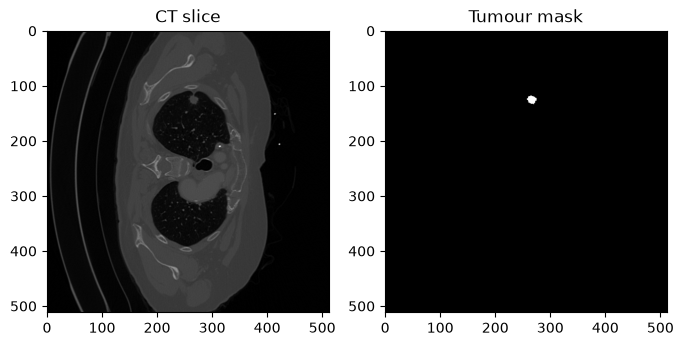

In [5]:
import nibabel as nib
import matplotlib.pyplot as plt

files = sorted([f for f in os.listdir(raw_data_dir + "/Task06_Lung/imagesTr")
                       if f.endswith(".nii.gz") and not f.startswith(".")])
print("Total labelled scans available:", len(files))

img = nib.load(f"{raw_data_dir}/Task06_Lung/imagesTr/{files[0]}").get_fdata()
mask = nib.load(f"{raw_data_dir}/Task06_Lung/labelsTr/{files[0]}").get_fdata()

tumour_slices = [i for i in range(mask.shape[2]) if mask[:, :, i].sum() > 0]
slice_idx = tumour_slices[len(tumour_slices) // 2]  # a middle tumour-containing slice

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img[:, :, slice_idx], cmap="gray"); axes[0].set_title("CT slice")
axes[1].imshow(mask[:, :, slice_idx], cmap="gray"); axes[1].set_title("Tumour mask")
plt.show()

### Windowing check to confirm the tumour is actually visible at this window

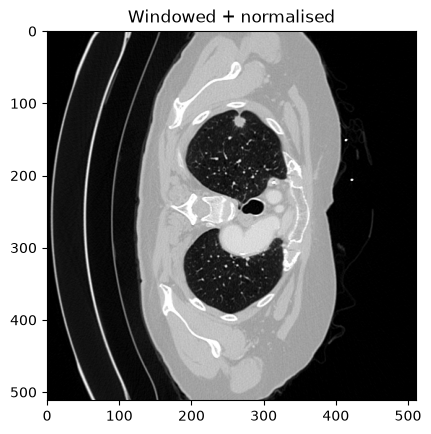

In [6]:
window = (-1000, 400)  # standard lung CT window in Hounsfield units
img_windowed = img[:, :, slice_idx].clip(*window)
img_norm = (img_windowed - window[0]) / (window[1] - window[0])

plt.imshow(img_norm, cmap="gray")
plt.title("Windowed + normalised")
plt.show()

### Overlay the tumour mask on the windowed CT slice to check mask still lines up correctly after windowing

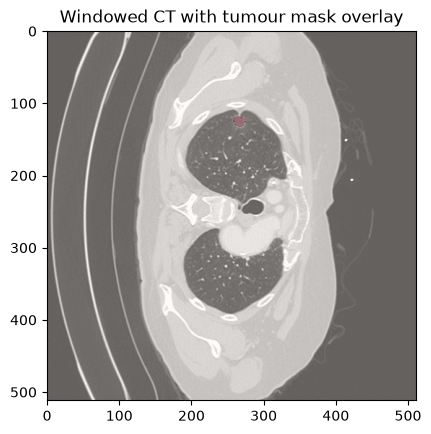

In [7]:
plt.imshow(img_norm, cmap="gray")
plt.imshow(mask[:, :, slice_idx], cmap="Reds", alpha=0.4)
plt.title("Windowed CT with tumour mask overlay")
plt.show()

# SECTION 6 — Extract 2D slices from all 63 scans

In [26]:
import glob

def extract_slices(img_path, mask_path, out_dir, patient_id, window=(-1000, 400)):
    nii_img = nib.load(img_path)
    img = nii_img.get_fdata()
    mask = nib.load(mask_path).get_fdata()
    img = np.clip(img, *window)
    img = (img - window[0]) / (window[1] - window[0])

    pos_slices = [i for i in range(img.shape[2]) if mask[:, :, i].sum() > 0]
    neg_candidates = [i for i in range(img.shape[2]) if mask[:, :, i].sum() == 0]
    n_neg = min(len(pos_slices), len(neg_candidates))
    neg_slices = list(np.random.choice(neg_candidates, size=n_neg, replace=False)) if n_neg > 0 else []

    os.makedirs(out_dir, exist_ok=True)
    for i in pos_slices + neg_slices:
        np.save(f"{out_dir}/{patient_id}_slice{i}_img.npy", img[:, :, i].astype(np.float32))
        np.save(f"{out_dir}/{patient_id}_slice{i}_mask.npy", mask[:, :, i].astype(np.float32))

    # Persist in-plane pixel spacing (mm/pixel) once per patient

    spacing_dir = "data/slices/spacing"
    os.makedirs(spacing_dir, exist_ok=True)
    sx, sy = nii_img.header.get_zooms()[:2]
    np.save(f"{spacing_dir}/{patient_id}_spacing.npy", np.array([sx, sy], dtype=np.float32))

    return len(pos_slices), len(neg_slices)

if len(glob.glob("data/slices/test/*_img.npy")) == 0:
    os.makedirs("data/slices/train", exist_ok=True)  # create train directory
    for fname in files:
        patient_id = fname.replace(".nii.gz", "")
        already_done = (
            glob.glob(f"data/slices/train/{patient_id}_slice*_img.npy") +
            glob.glob(f"data/slices/val/{patient_id}_slice*_img.npy") +
            glob.glob(f"data/slices/test/{patient_id}_slice*_img.npy")
        )  # safety check to avoid re-extracting slices if already done, anywhere in the split
        if already_done:
            print(f"{patient_id}: already extracted ({len(already_done)} slices found), skipping")
            continue
        pos, neg = extract_slices(
            f"{raw_data_dir}/Task06_Lung/imagesTr/{fname}",
            f"{raw_data_dir}/Task06_Lung/labelsTr/{fname}",
            "data/slices/train",
            patient_id,
        )
        print(f"{patient_id}: {pos} positive, {neg} negative slices extracted")
else:
    print("Slices already extracted and split, skipping")

spacing_dir = "data/slices/spacing"
os.makedirs(spacing_dir, exist_ok=True)
for fname in files:
    patient_id = fname.replace(".nii.gz", "")
    spacing_path = f"{spacing_dir}/{patient_id}_spacing.npy"
    if os.path.exists(spacing_path) != True:
        nii_img = nib.load(f"{raw_data_dir}/Task06_Lung/imagesTr/{fname}")
        sx, sy = nii_img.header.get_zooms()[:2]
        np.save(spacing_path, np.array([sx, sy], dtype=np.float32))
print(f"Spacing files present for {len(glob.glob(spacing_dir + '/*_spacing.npy'))}/{len(files)} patients.")

lung_001: 19 positive, 19 negative slices extracted
lung_003: 10 positive, 10 negative slices extracted
lung_004: 15 positive, 15 negative slices extracted
lung_005: 26 positive, 26 negative slices extracted
lung_006: 40 positive, 40 negative slices extracted
lung_009: 60 positive, 60 negative slices extracted
lung_010: 32 positive, 32 negative slices extracted
lung_014: 70 positive, 70 negative slices extracted
lung_015: 11 positive, 11 negative slices extracted
lung_016: 21 positive, 21 negative slices extracted
lung_018: 13 positive, 13 negative slices extracted
lung_020: 13 positive, 13 negative slices extracted
lung_022: 69 positive, 69 negative slices extracted
lung_023: 44 positive, 44 negative slices extracted
lung_025: 19 positive, 19 negative slices extracted
lung_026: 31 positive, 31 negative slices extracted
lung_027: 28 positive, 28 negative slices extracted
lung_028: 73 positive, 73 negative slices extracted
lung_029: 17 positive, 17 negative slices extracted
lung_031: 70

# SECTION 7 — Patient-level train/val/test split

In [27]:
if len(glob.glob("data/slices/test/*_img.npy")) == 0:
    patient_ids = [f.replace(".nii.gz", "") for f in files]
    random.seed(SEED)  # re-seed immediately before shuffling, for reproducibility
    random.shuffle(patient_ids)

    n_total = len(patient_ids)
    n_train = int(n_total * 0.70)
    n_val = int(n_total * 0.15)

    train_patients = patient_ids[:n_train]
    val_patients = patient_ids[n_train:n_train + n_val]
    test_patients = patient_ids[n_train + n_val:]

    print(f"Train: {len(train_patients)}  Val: {len(val_patients)}  Test: {len(test_patients)}")
else:
    print("Split into train, test, val already done, skipping")

Train: 44  Val: 9  Test: 10


# SECTION 8 — File sorting into train/val/test folders

In [ ]:
import shutil
import glob

if len(glob.glob("data/slices/test/*_img.npy")) == 0:
    os.makedirs("data/slices/val", exist_ok=True)
    os.makedirs("data/slices/test", exist_ok=True)

    def move_patient_files(patient_list, dest_folder):
        moved = 0
        for pid in patient_list:
            matching_files = glob.glob(f"data/slices/train/{pid}_slice*_img.npy") + \
                              glob.glob(f"data/slices/train/{pid}_slice*_mask.npy")
            for f in matching_files:
                shutil.move(f, os.path.join(dest_folder, os.path.basename(f)))
                moved += 1
        return moved

    n_val_files = move_patient_files(val_patients, "data/slices/val")
    n_test_files = move_patient_files(test_patients, "data/slices/test")

    for split in ["train", "val", "test"]:
        n = len(glob.glob(f"data/slices/{split}/*_img.npy"))
        print(f"{split}: {n} slices")
else:
    print("Files already sorted — skipping")

train: 2232 slices
val: 510 slices
test: 572 slices


127.0.0.1 - - [18/Aug/2026 00:08:10] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [18/Aug/2026 00:08:10] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [18/Aug/2026 00:09:20] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [18/Aug/2026 00:09:20] "GET /static/style.css HTTP/1.1" 200 -
127.0.0.1 - - [18/Aug/2026 00:09:20] "GET /favicon.ico HTTP/1.1" 404 -


# SECTION 9 — Dataset class with augmentation

In [11]:
from torch.utils.data import Dataset, DataLoader

class SliceDataset(Dataset):
    def __init__(self, files, augment=False):
        self.img_files = files
        self.augment = augment

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img = np.load(self.img_files[idx])
        mask = np.load(self.img_files[idx].replace("_img.npy", "_mask.npy"))

        if self.augment:
            if random.random() > 0.5:
                img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
            if random.random() > 0.5:
                img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
            if random.random() > 0.5:
                img = np.clip(img + np.random.normal(0, 0.03, img.shape), 0, 1)

        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()
        return img, mask

train_files = glob.glob("data/slices/train/*_img.npy")
val_files = glob.glob("data/slices/val/*_img.npy")
test_files = glob.glob("data/slices/test/*_img.npy")

train_loader = DataLoader(SliceDataset(train_files, augment=True), batch_size=8, shuffle=True)
val_loader = DataLoader(SliceDataset(val_files, augment=False), batch_size=8)

print("Train slices:", len(train_files), " Val slices:", len(val_files), " Test slices:", len(test_files))


Train slices: 2232  Val slices: 510  Test slices: 572


# SECTION 10 — Check tensor shapes correct before building the model

In [12]:
sample_img, sample_mask = next(iter(train_loader))
print("Image batch shape:", sample_img.shape)
print("Mask batch shape:", sample_mask.shape)
print("Image value range:", sample_img.min().item(), sample_img.max().item())
print("Mask unique values:", torch.unique(sample_mask))

Image batch shape: torch.Size([8, 1, 512, 512])
Mask batch shape: torch.Size([8, 1, 512, 512])
Image value range: 0.0 1.0
Mask unique values: tensor([0., 1.])


# SECTION 11 — Initialise Model: pretrained ResNet encoder + U-Net decoder

In [13]:
import segmentation_models_pytorch as smp

if os.path.exists(MODEL_PATH) != True:
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=1,
        classes=1,
    )
    model.to(device)
    print("Model loaded on:", device)
else:
    print(f"Checkpoint {MODEL_PATH} found — skipping model build/training")

Model loaded on: cuda


# SECTION 12 — Loss (Dice + BCE combined), optimizer, LR scheduler

In [ ]:
if os.path.exists(MODEL_PATH) != True:
    dice_loss_fn = smp.losses.DiceLoss(mode="binary")
    bce_loss_fn = smp.losses.SoftBCEWithLogitsLoss()

    def loss_fn(pred, target):
        return dice_loss_fn(pred, target) + bce_loss_fn(pred, target)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    def dice_score(pred, target, eps=1e-6):
        pred = (pred > 0.5).float()
        intersection = (pred * target).sum()
        return (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

    def train_one_epoch():
        model.train()
        total_loss = 0
        for img, mask in train_loader:
            img, mask = img.to(device), mask.to(device)
            optimizer.zero_grad()
            pred = model(img)
            loss = loss_fn(pred, mask)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    def validate():
        model.eval()
        total_dice = 0
        with torch.no_grad():
            for img, mask in val_loader:
                img, mask = img.to(device), mask.to(device)
                pred = torch.sigmoid(model(img))
                total_dice += dice_score(pred, mask).item()
        return total_dice / len(val_loader)

    print("Loss functions, optimizer, scheduler, and training functions all defined.")
else:
    print("Model exists, skipping defining as not needed")

Loss functions, optimizer, scheduler, and training functions all defined.


# SECTION 13 — Training loop

In [15]:
if os.path.exists(MODEL_PATH) != True:
    print("Model doesn't exist, starting training...")
    best_val_dice = 0
    for epoch in range(15):
        train_loss = train_one_epoch()
        val_dice = validate()
        scheduler.step(val_dice)
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1}/15 — train loss: {train_loss:.4f} — val Dice: {val_dice:.4f} — lr: {current_lr:.2e}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), "best_model.pt")
            print(f"  ---New best model saved (val Dice: {val_dice:.4f})")

    print(f"\nTraining complete. Best val Dice: {best_val_dice:.4f}")
else:
    print("Skipping training, not needed as model exists")

Model doesn't exist, starting training...
Epoch 1/15 — train loss: 1.3465 — val Dice: 0.0001 — lr: 1.00e-04
  ---New best model saved (val Dice: 0.0001)
Epoch 2/15 — train loss: 1.1180 — val Dice: 0.3102 — lr: 1.00e-04
  ---New best model saved (val Dice: 0.3102)
Epoch 3/15 — train loss: 1.0080 — val Dice: 0.2895 — lr: 1.00e-04
Epoch 4/15 — train loss: 0.8714 — val Dice: 0.3087 — lr: 1.00e-04
Epoch 5/15 — train loss: 0.6380 — val Dice: 0.4973 — lr: 1.00e-04
  ---New best model saved (val Dice: 0.4973)
Epoch 6/15 — train loss: 0.3836 — val Dice: 0.5668 — lr: 1.00e-04
  ---New best model saved (val Dice: 0.5668)
Epoch 7/15 — train loss: 0.3231 — val Dice: 0.5519 — lr: 1.00e-04
Epoch 8/15 — train loss: 0.2555 — val Dice: 0.5700 — lr: 1.00e-04
  ---New best model saved (val Dice: 0.5700)
Epoch 9/15 — train loss: 0.2569 — val Dice: 0.3542 — lr: 1.00e-04
Epoch 10/15 — train loss: 0.2568 — val Dice: 0.4135 — lr: 1.00e-04
Epoch 11/15 — train loss: 0.2370 — val Dice: 0.5269 — lr: 1.00e-04
Epoch

In [ ]:
import shutil

if os.path.exists(MODEL_PATH) == True:
    print("Creating checkpoint copy")
    shutil.copy("best_model.pt", "best_model_v2_full_dataset_dice0.5908.pt")
else:
    print("Skipping checkpoint copy, already exists.")

Creating checkpoint copy


127.0.0.1 - - [17/Aug/2026 22:03:11] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [17/Aug/2026 22:03:11] "GET /static/style.css HTTP/1.1" 200 -
127.0.0.1 - - [17/Aug/2026 22:03:11] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [17/Aug/2026 22:03:19] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [17/Aug/2026 22:03:19] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [17/Aug/2026 22:03:19] "GET /static/results/88c2f204881645f29183cb56c57694c2.png HTTP/1.1" 200 -
127.0.0.1 - - [17/Aug/2026 22:03:24] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [17/Aug/2026 22:03:24] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [17/Aug/2026 22:03:29] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [17/Aug/2026 22:03:29] "GET /static/style.css HTTP/1.1" 304 -
127.0.0.1 - - [17/Aug/2026 22:03:29] "GET /static/results/726de22050dc4ad685da4969fc7beaf5.png HTTP/1.1" 200 -


# SECTION 14 — Load the best checkpoint fresh, and define evaluation helpers

In [ ]:
from skimage.measure import label, regionprops

model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=1, classes=1)
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.to(device)
model.eval()

def predict_slice(img_path):
    img = np.load(img_path)
    mask = np.load(img_path.replace("_img.npy", "_mask.npy"))
    img_t = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(img_t)).cpu().numpy()[0, 0]
    return img, mask, prob

def mask_to_lesions(binary_mask):
    """Turn a binary mask into a list of discrete lesion candidates via connected components."""
    labeled = label(binary_mask)
    lesions = []
    for region in regionprops(labeled):
        # equivalent_diameter_area is the newer scikit-image name; fall back for older versions
        diameter = getattr(region, "equivalent_diameter_area", None)
        if diameter is None:
            diameter = region.equivalent_diameter
        lesions.append({"centroid": region.centroid, "diameter": diameter})
    return lesions

def match_lesions(pred_lesions, gt_lesions, dist_threshold=15):
    """Match predicted lesions to ground-truth lesions by centroid distance."""
    matched_gt = set()
    tp, fp = 0, 0
    for p in pred_lesions:
        found = False
        for i, g in enumerate(gt_lesions):
            if i in matched_gt:
                continue
            dist = np.linalg.norm(np.array(p["centroid"]) - np.array(g["centroid"]))
            if dist < dist_threshold:
                matched_gt.add(i)
                found = True
                break
        if found:
            tp += 1
        else:
            fp += 1
    fn = len(gt_lesions) - len(matched_gt)
    return tp, fp, fn, matched_gt

# Per-patient in-plane spacing lookup (mm/pixel) helps convert
# lesion diameter from pixels to millimetres before thresholding.
_spacing_cache = {}
def get_patient_mm_per_pixel(f):
    patient_id = os.path.basename(f).split("_slice")[0]
    if patient_id not in _spacing_cache:
        sx, sy = np.load(f"data/slices/spacing/{patient_id}_spacing.npy")
        _spacing_cache[patient_id] = (sx + sy) / 2
    return _spacing_cache[patient_id]


def dice_score(pred, target, eps=1e-6):
    pred, target = pred.flatten(), target.flatten()
    intersection = (pred * target).sum()
    return (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

print("dice_score redefined for NumPy-array evaluation")

C:\Users\ag\AppData\Local\Temp\ipykernel_21456\1471055595.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt", map_location=

dice_score redefined for NumPy-array evaluation


# SECTION 15 — Full test-set evaluation

In [18]:
SMALL_DIAM_THRESHOLD = 10  # mm — converted from pixel diameter using per-patient in-plane spacing

overall_dice_scores = []
foreground_dice_scores = []
foreground_iou_scores = []
totals = {"tp": 0, "fp": 0, "fn": 0,
          "small_tp": 0, "small_fn": 0,
          "large_tp": 0, "large_fn": 0}

def iou_score(pred, target, eps=1e-6):
    pred, target = pred.flatten(), target.flatten()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + eps) / (union + eps)


for f in test_files:
    img, mask, prob = predict_slice(f)
    pred_binary = (prob > 0.5).astype(np.uint8)

    slice_dice = dice_score(pred_binary, mask)
    overall_dice_scores.append(slice_dice)
    if mask.sum() > 0:
        foreground_dice_scores.append(slice_dice)
        foreground_iou_scores.append(iou_score(pred_binary, mask))

    pred_lesions = mask_to_lesions(pred_binary)
    gt_lesions = mask_to_lesions(mask.astype(np.uint8))
    tp, fp, fn, matched_gt = match_lesions(pred_lesions, gt_lesions)
    totals["tp"] += tp
    totals["fp"] += fp
    totals["fn"] += fn

    mm_per_px = get_patient_mm_per_pixel(f)
    for i, g in enumerate(gt_lesions):
        diameter_mm = g["diameter"] * mm_per_px
        is_small = diameter_mm < SMALL_DIAM_THRESHOLD
        if i in matched_gt:
            totals["small_tp" if is_small else "large_tp"] += 1
        else:
            totals["small_fn" if is_small else "large_fn"] += 1

print(f"Overall Dice (all test slices): {np.mean(overall_dice_scores):.4f}")
print(f"Foreground Dice (lesion-containing slices only): {np.mean(foreground_dice_scores):.4f}")
print(f"Foreground IoU (lesion-containing slices only): {np.mean(foreground_iou_scores):.4f}")
print(f"Number of lesion-containing test slices: {len(foreground_dice_scores)}")

sensitivity = totals["tp"] / (totals["tp"] + totals["fn"] + 1e-6)
fp_per_slice = totals["fp"] / len(test_files)
precision = totals["tp"] / (totals["tp"] + totals["fp"] + 1e-6)
f1 = 2 * precision * sensitivity / (precision + sensitivity + 1e-6)
print(f"Lesion-level sensitivity: {sensitivity:.4f}")
print(f"False positives per slice: {fp_per_slice:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 score: {f1:.4f}")

small_total = totals["small_tp"] + totals["small_fn"]
large_total = totals["large_tp"] + totals["large_fn"]
small_sens = totals["small_tp"] / (small_total + 1e-6)
large_sens = totals["large_tp"] / (large_total + 1e-6)
print(f"Small-lesion sensitivity: {small_sens:.4f}  ({totals['small_tp']}/{small_total})")
print(f"Large-lesion sensitivity: {large_sens:.4f}  ({totals['large_tp']}/{large_total})")

Overall Dice (all test slices): 0.6542
Foreground Dice (lesion-containing slices only): 0.4413
Foreground IoU (lesion-containing slices only): 0.3719
Number of lesion-containing test slices: 286
Lesion-level sensitivity: 0.5411
False positives per slice: 0.1766
Precision: 0.6287
F1 score: 0.5816
Small-lesion sensitivity: 0.1857  (13/70)
Large-lesion sensitivity: 0.6423  (158/246)


# SECTION 16 — Find and save success/failure case examples

Success case: data/slices/test\lung_026_slice171_img.npy Dice: 0.9467021982189533
Failure case: data/slices/test\lung_092_slice118_img.npy Dice: 4.3859648819705165e-09


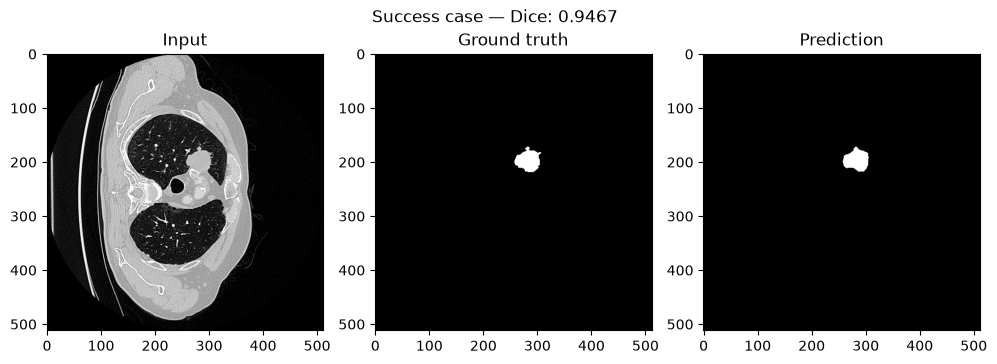

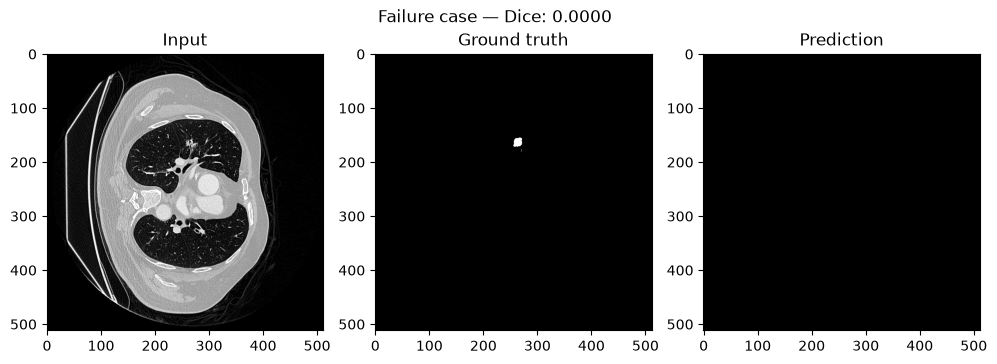

In [ ]:
candidates = []
for f in test_files:
    img, mask, prob = predict_slice(f)
    if mask.sum() == 0:
        continue
    pred_binary = (prob > 0.5).astype(np.uint8)
    slice_dice = dice_score(pred_binary, mask)
    gt_lesions = mask_to_lesions(mask.astype(np.uint8))
    mm_per_px = get_patient_mm_per_pixel(f)
    has_large_lesion = any(g["diameter"] * mm_per_px >= SMALL_DIAM_THRESHOLD for g in gt_lesions)
    has_small_lesion = any(g["diameter"] * mm_per_px < SMALL_DIAM_THRESHOLD for g in gt_lesions)
    candidates.append({"file": f, "dice": slice_dice,
                        "has_large_lesion": has_large_lesion,
                        "has_small_lesion": has_small_lesion})

# Best success case: highest Dice among slices with a large lesion
success_candidates = sorted([c for c in candidates if c["has_large_lesion"]],
                             key=lambda c: c["dice"], reverse=True)
file_number = 4
success_file = success_candidates[file_number]["file"]

# A clear failure case: lowest Dice among slices with a small lesion
failure_candidates = sorted([c for c in candidates if c["has_small_lesion"]],
                             key=lambda c: c["dice"])
failure_file = failure_candidates[file_number]["file"]

print("Success case:", success_file, "Dice:", success_candidates[file_number]["dice"])
print("Failure case:", failure_file, "Dice:", failure_candidates[file_number]["dice"])

def save_case_figure(file_path, label_text, out_name):
    img, mask, prob = predict_slice(file_path)
    pred_binary = (prob > 0.5).astype(np.uint8)
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    axes[0].imshow(img, cmap="gray"); axes[0].set_title("Input")
    axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Ground truth")
    axes[2].imshow(pred_binary, cmap="gray"); axes[2].set_title("Prediction")
    plt.suptitle(f"{label_text} — Dice: {dice_score(pred_binary, mask):.4f}")
    plt.tight_layout()
    plt.savefig(out_name, dpi=150)
    plt.show()

save_case_figure(success_file, "Success case", "success_case_example.png")
save_case_figure(failure_file, "Failure case", "failure_case_example.png")

# SECTION 17 — Explainability: native heatmap + Grad-CAM at TWO layers
### Comparing layer2 (shallower, more spatially precise) against layer4 (deeper, more contextual)

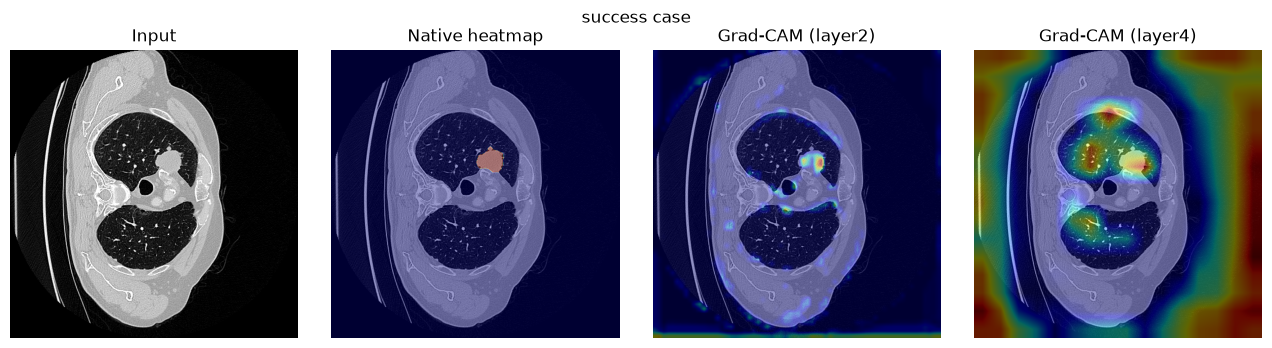

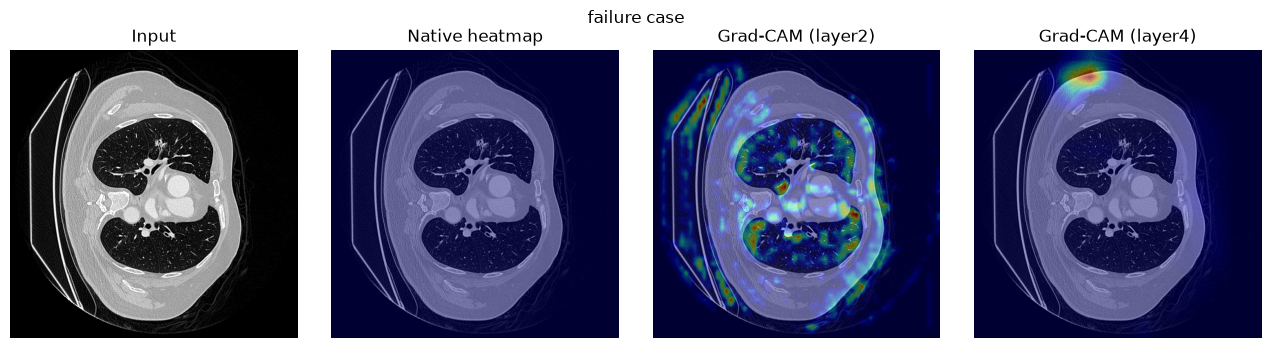

In [ ]:
from pytorch_grad_cam import GradCAM

class SegmentationModelOutputTarget:
    """Tells Grad-CAM which output to explain — here, a given mask region."""
    def __init__(self, mask):
        self.mask = torch.from_numpy(mask).float()
    def __call__(self, model_output):
        return (model_output[0, :] * self.mask.to(model_output.device)).sum()

def run_gradcam_comparison(file_path, title=""):
    img, mask, prob = predict_slice(file_path)
    img_tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)
    img_tensor.requires_grad_(True)

    # Explain against ground truth so a slice with a missed lesion still shows
    # whether the encoder had any awareness of the true lesion location.
    targets = [SegmentationModelOutputTarget(mask.astype(np.uint8))]

    cam_shallow = GradCAM(model=model, target_layers=[model.encoder.layer2[-1]])
    cam_deep = GradCAM(model=model, target_layers=[model.encoder.layer4[-1]])
    grayscale_cam_shallow = cam_shallow(input_tensor=img_tensor, targets=targets)[0]
    grayscale_cam_deep = cam_deep(input_tensor=img_tensor, targets=targets)[0]

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
    axes[0].imshow(img, cmap="gray"); axes[0].set_title("Input"); axes[0].axis("off")
    axes[1].imshow(img, cmap="gray")
    axes[1].imshow(prob, cmap="jet", alpha=0.4); axes[1].set_title("Native heatmap"); axes[1].axis("off")
    axes[2].imshow(img, cmap="gray")
    axes[2].imshow(grayscale_cam_shallow, cmap="jet", alpha=0.4); axes[2].set_title("Grad-CAM (layer2)"); axes[2].axis("off")
    axes[3].imshow(img, cmap="gray")
    axes[3].imshow(grayscale_cam_deep, cmap="jet", alpha=0.4); axes[3].set_title("Grad-CAM (layer4)"); axes[3].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"gradcam_comparison_{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

run_gradcam_comparison(success_file, "success case")
run_gradcam_comparison(failure_file, "failure case")

# SECTION 18 — Robustness under synthetic noise

sigma=0.0: Dice=0.4413, sensitivity=0.5411, FP/slice=0.1766
sigma=0.02: Dice=0.4306, sensitivity=0.5380, FP/slice=0.1801
sigma=0.05: Dice=0.3446, sensitivity=0.4462, FP/slice=0.1556
sigma=0.1: Dice=0.1830, sensitivity=0.2247, FP/slice=0.0769


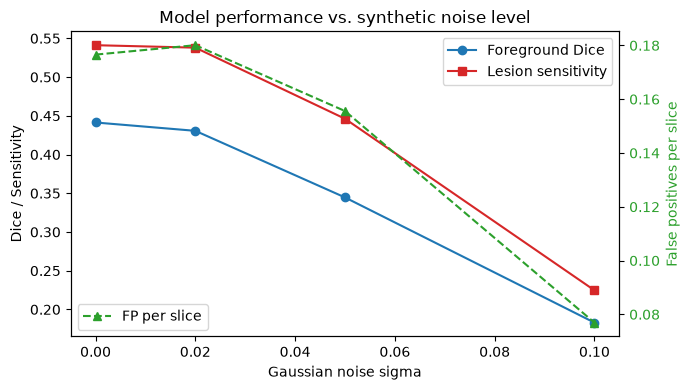

In [ ]:
def add_gaussian_noise(img, sigma):
    noisy = img + np.random.normal(0, sigma, img.shape)
    return np.clip(noisy, 0, 1).astype(np.float32)

def evaluate_at_noise_level(sigma):
    np.random.seed(SEED)
    dice_scores = []
    totals = {"tp": 0, "fp": 0, "fn": 0}

    for f in test_files:
        img = np.load(f)
        mask = np.load(f.replace("_img.npy", "_mask.npy"))

        noisy_img = add_gaussian_noise(img, sigma)
        img_tensor = torch.tensor(noisy_img).unsqueeze(0).unsqueeze(0).float().to(device)
        with torch.no_grad():
            prob = torch.sigmoid(model(img_tensor)).cpu().numpy()[0, 0]
        pred_binary = (prob > 0.5).astype(np.uint8)

        if mask.sum() > 0:
            dice_scores.append(dice_score(pred_binary, mask))

        pred_lesions = mask_to_lesions(pred_binary)
        gt_lesions = mask_to_lesions(mask.astype(np.uint8))
        tp, fp, fn, _ = match_lesions(pred_lesions, gt_lesions)
        totals["tp"] += tp
        totals["fp"] += fp
        totals["fn"] += fn

    mean_dice = np.mean(dice_scores) if dice_scores else 0
    sensitivity = totals["tp"] / (totals["tp"] + totals["fn"] + 1e-6)
    fp_per_slice = totals["fp"] / len(test_files)
    return mean_dice, sensitivity, fp_per_slice

noise_levels = [0.0, 0.02, 0.05, 0.1]
results_by_noise = []
for sigma in noise_levels:
    mean_dice, sensitivity, fp_per_slice = evaluate_at_noise_level(sigma)
    results_by_noise.append({"sigma": sigma, "dice": mean_dice, "sensitivity": sensitivity, "fp_per_slice": fp_per_slice})
    print(f"sigma={sigma}: Dice={mean_dice:.4f}, sensitivity={sensitivity:.4f}, FP/slice={fp_per_slice:.4f}")

sigmas = [r["sigma"] for r in results_by_noise]
dices = [r["dice"] for r in results_by_noise]
sensitivities = [r["sensitivity"] for r in results_by_noise]
fp_rates = [r["fp_per_slice"] for r in results_by_noise]

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sigmas, dices, marker="o", color="tab:blue", label="Foreground Dice")
ax1.plot(sigmas, sensitivities, marker="s", color="tab:red", label="Lesion sensitivity")
ax1.set_xlabel("Gaussian noise sigma")
ax1.set_ylabel("Dice / Sensitivity")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(sigmas, fp_rates, marker="^", color="tab:green", linestyle="--", label="FP per slice")
ax2.set_ylabel("False positives per slice", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.legend(loc="lower left")

plt.title("Model performance vs. synthetic noise level")
fig.tight_layout()
plt.savefig("robustness_curve.png", dpi=150)
plt.show()

# SECTION 19 — Initialise variables and functions for Flask web application
### Lets a user upload one CT slice image (PNG/JPG) and get back the model's lesion detections overlaid on it

In [ ]:
import uuid
from flask import Flask, render_template, request, url_for
from PIL import Image

IMG_SIZE = 512                         # resize input to match training size
THRESHOLD = 0.5                        # probability threshold for lesion mask
UPLOAD_FOLDER = os.path.join("static", "results")

def preprocess_image(pil_img):
    """Convert an uploaded image to a normalised tensor matching training preprocessing."""
    pil_img = pil_img.convert("L").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(pil_img).astype(np.float32) / 255.0  # scale to [0,1]
    tensor = torch.tensor(arr).unsqueeze(0).unsqueeze(0).float()  # [1,1,H,W]
    return arr, tensor


def run_inference(tensor):
    with torch.no_grad():
        logits = model(tensor.to(device))
        prob_map = torch.sigmoid(logits).cpu().numpy()[0, 0]
    return prob_map


def mask_to_lesions_web(prob_map, threshold=THRESHOLD):
    """Turn a probability map into discrete lesion detections"""
    binary = (prob_map > threshold).astype(np.uint8)
    labeled = label(binary)
    lesions = []
    for region in regionprops(labeled, intensity_image=prob_map):
        # equivalent_diameter_area is the newer scikit-image name; fall back for older versions
        diameter = getattr(region, "equivalent_diameter_area", None)
        if diameter is None:
            diameter = region.equivalent_diameter
        lesions.append({
            "centroid": (round(float(region.centroid[0]), 1), round(float(region.centroid[1]), 1)),
            "bbox": region.bbox,  # (min_row, min_col, max_row, max_col)
        })
    return lesions


def save_overlay(arr, prob_map, lesions, out_path):
    """Save a side by side original + heatmap-overlay image, with bounding boxes drawn."""
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(arr, cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    axes[1].imshow(arr, cmap="gray")
    axes[1].imshow(prob_map, cmap="jet", alpha=0.4)
    for lesion in lesions:
        min_row, min_col, max_row, max_col = lesion["bbox"]
        rect = patches.Rectangle(
            (min_col, min_row), max_col - min_col, max_row - min_row,
            linewidth=1.5, edgecolor="lime", facecolor="none"
        )
        axes[1].add_patch(rect)
    axes[1].set_title(f"Detections: {len(lesions)}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.close(fig)


os.makedirs(UPLOAD_FOLDER, exist_ok=True)

app = Flask(__name__)
app.config["UPLOAD_FOLDER"] = UPLOAD_FOLDER


@app.route("/", methods=["GET"])
def index():
    return render_template("index.html")


@app.route("/predict", methods=["POST"])
def predict():
    if "image" not in request.files or request.files["image"].filename == "":
        return render_template("index.html", error="Please choose an image file.")

    file = request.files["image"]
    pil_img = Image.open(file.stream)

    arr, tensor = preprocess_image(pil_img)
    prob_map = run_inference(tensor)
    lesions = mask_to_lesions_web(prob_map)

    result_filename = f"{uuid.uuid4().hex}.png"
    result_path = os.path.join(app.config["UPLOAD_FOLDER"], result_filename)
    save_overlay(arr, prob_map, lesions, result_path)

    return render_template(
        "result.html",
        result_image=url_for("static", filename=f"results/{result_filename}"),
        lesions=lesions,
        num_lesions=len(lesions),
    )


In [ ]:
import threading

def run_app():
    app.run(host="127.0.0.1", port=5000, use_reloader=False, threaded=False, debug=True)

# Need threading as doesnt run Flask in jupyter notebok
threading.Thread(target=run_app, daemon=True).start()
print("Flask running in background at http://127.0.0.1:5000")

Flask running in background at http://127.0.0.1:5000
 * Serving Flask app '__main__'


 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
